# Worked Example — Calendar & Event Features for Website Traffic Forecasting


In the main chapter, I used sales data to show how calendar and event features improve forecasting.  
In this exercises notebook, I apply the same idea to a **new dataset**: daily website traffic.

The goal is to show that the technique generalizes across domains.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(123)

# create synthetic dataset: 2023 website visits
date_range = pd.date_range("2023-01-01", "2023-06-30", freq="D")
df2 = pd.DataFrame({"date": date_range})

df2["day_of_week"] = df2["date"].dt.dayofweek
df2["month"] = df2["date"].dt.month
df2["is_weekend"] = df2["day_of_week"].isin([5, 6]).astype(int)
df2["is_campaign"] = (df2["date"].dt.day == 10).astype(int)      # marketing campaign every 10th day

noise = np.random.normal(0, 30, len(df2))
df2["visits"] = 400 + 30*df2["is_weekend"] + 50*df2["is_campaign"] + noise
df2.head()


,date,day_of_week,month,is_weekend,is_campaign,visits
0,2023-01-01,6,1,1,0,397.431082
1,2023-01-02,0,1,0,0,429.920363
2,2023-01-03,1,1,0,0,408.489355
3,2023-01-04,2,1,0,0,354.811159
4,2023-01-05,3,1,0,0,382.641992


## Website visits over time with campaign days highlighted


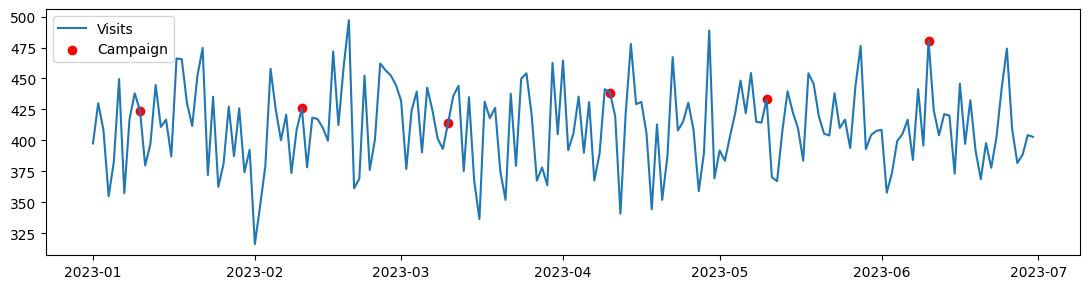

In [2]:
plt.figure(figsize=(11,3))
plt.plot(df2["date"], df2["visits"], label="Visits")
plt.scatter(df2[df2["is_campaign"]==1]["date"], df2[df2["is_campaign"]==1]["visits"], color="red", label="Campaign")
plt.legend(); plt.tight_layout(); plt.show()


Campaign days clearly cause spikes in website visits, meaning event features should help the forecasting model.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

feature_cols = ["day_of_week", "month", "is_weekend", "is_campaign"]
target = "visits"

X = df2[feature_cols]
y = df2[target]

categorical = ["day_of_week", "month"]
numeric = ["is_weekend", "is_campaign"]

pre = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown='ignore'), categorical),
    ("num", "passthrough", numeric)
])

model = Pipeline([
    ("preprocessor", pre),
    ("regressor", LinearRegression())
])

# train 80% → test 20% (time-based)
split = int(len(df2)*0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate RMSE manually as squared=False is deprecated
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(rmse, r2)

25.309966451357493 0.2313939879555328


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


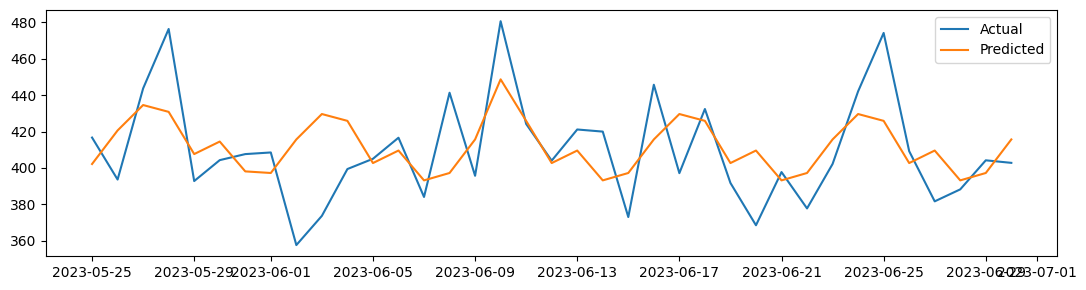

In [7]:
plt.figure(figsize=(11,3))
plt.plot(df2["date"].iloc[split:], y_test.values, label="Actual")
plt.plot(df2["date"].iloc[split:], y_pred, label="Predicted")
plt.legend(); plt.tight_layout(); plt.show()


The model follows the overall pattern of website visits.  
Calendar and event variables (especially `is_weekend` and `is_campaign`) help explain traffic spikes.


## Exercises
If I want to extend this notebook, I can try:

1) Add a new feature `is_holiday` and check whether RMSE improves.  
2) Train a model *without* `is_campaign` and compare results to see how removing an event feature affects accuracy.  
3) Change the time-based split (e.g., 70/30) and observe whether the model becomes less stable with less training data.


This short exercise shows that the same calendar/event feature engineering used on sales forecasting also improves forecasting for website traffic.  
The idea is transferable: when events and time patterns causally influence the target, models perform better when those features are included.


License

MIT License

Copyright (c) 2025 Chinmay Sawant

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.